In [76]:
import pandas as pd

In [77]:
gemma = pd.read_excel("back_translation_en.xlsx")
marian = pd.read_excel("marian_bt.xlsx")
nllb = pd.read_excel("nllb_bt.xlsx")
mbart = pd.read_excel("mbart_bt.xlsx")

In [78]:

gemma = gemma.rename(columns={
    "orginal_sen": "en_original",
    "translate_hi": "hi_gemma",
    "back_translation_en": "back_gemma"
})


marian = marian.rename(columns={
    "hi_translation": "hi_marian",
    "en_backtranslation": "back_marian"
})


nllb = nllb.rename(columns={
    "hi_translation": "hi_nllb",
    "en_backtranslation": "back_nllb"
})

mbart = mbart.rename(columns={
    "hi_translation": "hi_mbart",
    "en_backtranslation": "back_mbart"
})

In [79]:
gemma = gemma[["sentence_id", "en_original", "hi_gemma", "back_gemma"]]
marian = marian[["sentence_id", "hi_marian", "back_marian"]]
nllb = nllb[["sentence_id", "hi_nllb", "back_nllb"]]
mbart = mbart[["sentence_id", "hi_mbart", "back_mbart"]]

In [80]:
comparison = gemma.merge(marian, on="sentence_id") \
                  .merge(nllb, on="sentence_id") \
                  .merge(mbart, on="sentence_id")

comparison.head()

,sentence_id,en_original,hi_gemma,back_gemma,hi_marian,back_marian,hi_nllb,back_nllb,hi_mbart,back_mbart
0,1,Let's try something.,"चलिए, हम कुछ कोशिश करते हैं।",Let's try something.,चलो कुछ कोशिश करते हैं.,Let's try something.,चलो कुछ कोशिश करते हैं.,Let's try something.,चलो कुछ कोशिश करें।,Let 's try something.
1,2,I have to go to sleep.,मुझे सोने जाना है।,I have to go to sleep.,मुझे नींद में जाना है.,I have to go to sleep.,मुझे सोने जाना है.,I have to go to bed.,मुझे सोने जाना है।,I have to go to bed.
2,3,Today is June 18th and it is Muiriel's birthday!,आज 18 जून है और यह मियरीएल का जन्मदिन है!,"Today is June 18th, and it's the birthday of M...",आज जून 18 वीं है और यह Marris का जन्मदिन है!,Today is June 18th and it's Marky's birthday!,आज 18 जून है और यह म्यूरियल का जन्मदिन है!,Today is June 18th and it's Muriel's birthday!,आज 18 जून है और मुइरीएल का जन्मदिन है!,Today is June 18th and Mauriel 's birthday!
3,4,Muiriel is 20 now.,मुइरिल अब 20 साल की है।,Muiril is now 20 years old.,मुंबरी अब 20 साल की है.,Muller is now 20 years old.,मुरियल अब 20 साल का है।,Muriel is now 20 years old.,मुइरीएल अब 20 साल का है।,Muriel is now 20 years old.
4,5,"The password is ""Muiriel"".","पासवर्ड ""म्युरियल"" है।","The password is ""Myurial"".","पासवर्ड है ""metel""","Password is ""mel""","पासवर्ड ""Muiriel"" है।","The password is ""Muiriel"".","पासवर्ड ""मुइरिएल"" है।","The password is ""Mauriel""."


In [44]:
comparison.to_excel("comparison_all.xlsx", index=False)
print("Saved comparison_all.xlsx")

Saved comparison_all.xlsx


In [81]:
comparison[["sentence_id", "en_original", "back_gemma", "back_marian", "back_nllb","back_mbart"]].head(5)


,sentence_id,en_original,back_gemma,back_marian,back_nllb,back_mbart
0,1,Let's try something.,Let's try something.,Let's try something.,Let's try something.,Let 's try something.
1,2,I have to go to sleep.,I have to go to sleep.,I have to go to sleep.,I have to go to bed.,I have to go to bed.
2,3,Today is June 18th and it is Muiriel's birthday!,"Today is June 18th, and it's the birthday of M...",Today is June 18th and it's Marky's birthday!,Today is June 18th and it's Muriel's birthday!,Today is June 18th and Mauriel 's birthday!
3,4,Muiriel is 20 now.,Muiril is now 20 years old.,Muller is now 20 years old.,Muriel is now 20 years old.,Muriel is now 20 years old.
4,5,"The password is ""Muiriel"".","The password is ""Myurial"".","Password is ""mel""","The password is ""Muiriel"".","The password is ""Mauriel""."


In [85]:
comparison[["sentence_id","hi_gemma", "hi_marian", "hi_nllb","hi_mbart"]].head(5)

,sentence_id,hi_gemma,hi_marian,hi_nllb,hi_mbart
0,1,"चलिए, हम कुछ कोशिश करते हैं।",चलो कुछ कोशिश करते हैं.,चलो कुछ कोशिश करते हैं.,चलो कुछ कोशिश करें।
1,2,मुझे सोने जाना है।,मुझे नींद में जाना है.,मुझे सोने जाना है.,मुझे सोने जाना है।
2,3,आज 18 जून है और यह मियरीएल का जन्मदिन है!,आज जून 18 वीं है और यह Marris का जन्मदिन है!,आज 18 जून है और यह म्यूरियल का जन्मदिन है!,आज 18 जून है और मुइरीएल का जन्मदिन है!
3,4,मुइरिल अब 20 साल की है।,मुंबरी अब 20 साल की है.,मुरियल अब 20 साल का है।,मुइरीएल अब 20 साल का है।
4,5,"पासवर्ड ""म्युरियल"" है।","पासवर्ड है ""metel""","पासवर्ड ""Muiriel"" है।","पासवर्ड ""मुइरिएल"" है।"


In [13]:
!pip install sentence-transformers


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
!pip install sentence-transformers scikit-learn


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [47]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

In [48]:
model = SentenceTransformer("all-MiniLM-L6-v2")

In [50]:
def compute_similarity(text1, text2):
    text1 = str(text1)
    text2 = str(text2)
    
    emb1 = model.encode(text1)
    emb2 = model.encode(text2)
    
    sim = cosine_similarity([emb1], [emb2])[0][0]
    return sim

In [51]:
comparison["sim_gemma"] = comparison.apply(
    lambda x: compute_similarity(x["en_original"], x["back_gemma"]), axis=1
)

comparison["sim_marian"] = comparison.apply(
    lambda x: compute_similarity(x["en_original"], x["back_marian"]), axis=1
)

comparison["sim_nllb"] = comparison.apply(
    lambda x: compute_similarity(x["en_original"], x["back_nllb"]), axis=1
)

comparison["sim_mbart"] = comparison.apply(
    lambda x: compute_similarity(x["en_original"], x["back_mbart"]), axis=1
)
comparison.head()

,sentence_id,en_original,hi_gemma,back_gemma,hi_marian,back_marian,hi_nllb,back_nllb,hi_mbart,back_mbart,sim_gemma,sim_marian,sim_nllb,sim_mbart
0,1,Let's try something.,"चलिए, हम कुछ कोशिश करते हैं।",Let's try something.,चलो कुछ कोशिश करते हैं.,Let's try something.,चलो कुछ कोशिश करते हैं.,Let's try something.,चलो कुछ कोशिश करें।,Let 's try something.,1.000000,1.000000,1.000000,1.000000
1,2,I have to go to sleep.,मुझे सोने जाना है।,I have to go to sleep.,मुझे नींद में जाना है.,I have to go to sleep.,मुझे सोने जाना है.,I have to go to bed.,मुझे सोने जाना है।,I have to go to bed.,1.000000,1.000000,0.929535,0.929535
2,3,Today is June 18th and it is Muiriel's birthday!,आज 18 जून है और यह मियरीएल का जन्मदिन है!,"Today is June 18th, and it's the birthday of M...",आज जून 18 वीं है और यह Marris का जन्मदिन है!,Today is June 18th and it's Marky's birthday!,आज 18 जून है और यह म्यूरियल का जन्मदिन है!,Today is June 18th and it's Muriel's birthday!,आज 18 जून है और मुइरीएल का जन्मदिन है!,Today is June 18th and Mauriel 's birthday!,0.607721,0.663539,0.684408,0.677153
3,4,Muiriel is 20 now.,मुइरिल अब 20 साल की है।,Muiril is now 20 years old.,मुंबरी अब 20 साल की है.,Muller is now 20 years old.,मुरियल अब 20 साल का है।,Muriel is now 20 years old.,मुइरीएल अब 20 साल का है।,Muriel is now 20 years old.,0.818054,0.588668,0.459096,0.459096
4,5,"The password is ""Muiriel"".","पासवर्ड ""म्युरियल"" है।","The password is ""Myurial"".","पासवर्ड है ""metel""","Password is ""mel""","पासवर्ड ""Muiriel"" है।","The password is ""Muiriel"".","पासवर्ड ""मुइरिएल"" है।","The password is ""Mauriel"".",0.721748,0.639109,1.000000,0.758396


In [53]:
comparison[[
    "sentence_id",
    "en_original",
    "back_gemma", "sim_gemma",
    "back_marian", "sim_marian",
    "back_nllb", "sim_nllb",
    "back_mbart", "sim_mbart"
]].head(10)

,sentence_id,en_original,back_gemma,sim_gemma,back_marian,sim_marian,back_nllb,sim_nllb,back_mbart,sim_mbart
0,1,Let's try something.,Let's try something.,1.000000,Let's try something.,1.000000,Let's try something.,1.000000,Let 's try something.,1.000000
1,2,I have to go to sleep.,I have to go to sleep.,1.000000,I have to go to sleep.,1.000000,I have to go to bed.,0.929535,I have to go to bed.,0.929535
2,3,Today is June 18th and it is Muiriel's birthday!,"Today is June 18th, and it's the birthday of M...",0.607721,Today is June 18th and it's Marky's birthday!,0.663539,Today is June 18th and it's Muriel's birthday!,0.684408,Today is June 18th and Mauriel 's birthday!,0.677153
3,4,Muiriel is 20 now.,Muiril is now 20 years old.,0.818054,Muller is now 20 years old.,0.588668,Muriel is now 20 years old.,0.459096,Muriel is now 20 years old.,0.459096
4,5,"The password is ""Muiriel"".","The password is ""Myurial"".",0.721748,"Password is ""mel""",0.639109,"The password is ""Muiriel"".",1.000000,"The password is ""Mauriel"".",0.758396
5,6,I will be back soon.,I will be back soon.,1.000000,I'll be back soon.,0.964904,I'll be back soon.,0.964904,I 'll be back soon.,0.964904
6,7,I'm at a loss for words.,I am at a loss for words.,0.955901,I'm in a loss for words.,0.938854,I'm losing my words.,0.769742,I 'm losing words.,0.796366
7,8,This is never going to end.,This will never end.,0.897109,It's never going to end.,0.884280,It will never end.,0.824961,It will never end.,0.824961
8,9,I just don't know what to say.,I don't know what to say.,0.905477,I don't know just what to say.,0.911993,I just don't know what to say.,1.000000,I just don 't know what to say.,1.000000
9,10,That was an evil bunny.,He was a wicked rabbit.,0.733828,It was a bad shit.,0.326616,It was a wicked rabbit.,0.759463,It was a bad calf.,0.379622


In [54]:
print("Average Cosine Similarity Scores")
print("Gemma :", comparison["sim_gemma"].mean())
print("Marian:", comparison["sim_marian"].mean())
print("NLLB  :", comparison["sim_nllb"].mean())
print("mBART :", comparison["sim_mbart"].mean())

Average Cosine Similarity Scores
Gemma : 0.25281325
Marian: 0.8143202
NLLB  : 0.8763379
mBART : 0.8383664


In [55]:
threshold = 0.80

comparison["acc_gemma"] = comparison["sim_gemma"] >= threshold
comparison["acc_marian"] = comparison["sim_marian"] >= threshold
comparison["acc_nllb"] = comparison["sim_nllb"] >= threshold
comparison["acc_mbart"] = comparison["sim_mbart"] >= threshold

comparison.head()

,sentence_id,en_original,hi_gemma,back_gemma,hi_marian,back_marian,hi_nllb,back_nllb,hi_mbart,back_mbart,sim_gemma,sim_marian,sim_nllb,sim_mbart,acc_gemma,acc_marian,acc_nllb,acc_mbart
0,1,Let's try something.,"चलिए, हम कुछ कोशिश करते हैं।",Let's try something.,चलो कुछ कोशिश करते हैं.,Let's try something.,चलो कुछ कोशिश करते हैं.,Let's try something.,चलो कुछ कोशिश करें।,Let 's try something.,1.000000,1.000000,1.000000,1.000000,True,True,True,True
1,2,I have to go to sleep.,मुझे सोने जाना है।,I have to go to sleep.,मुझे नींद में जाना है.,I have to go to sleep.,मुझे सोने जाना है.,I have to go to bed.,मुझे सोने जाना है।,I have to go to bed.,1.000000,1.000000,0.929535,0.929535,True,True,True,True
2,3,Today is June 18th and it is Muiriel's birthday!,आज 18 जून है और यह मियरीएल का जन्मदिन है!,"Today is June 18th, and it's the birthday of M...",आज जून 18 वीं है और यह Marris का जन्मदिन है!,Today is June 18th and it's Marky's birthday!,आज 18 जून है और यह म्यूरियल का जन्मदिन है!,Today is June 18th and it's Muriel's birthday!,आज 18 जून है और मुइरीएल का जन्मदिन है!,Today is June 18th and Mauriel 's birthday!,0.607721,0.663539,0.684408,0.677153,False,False,False,False
3,4,Muiriel is 20 now.,मुइरिल अब 20 साल की है।,Muiril is now 20 years old.,मुंबरी अब 20 साल की है.,Muller is now 20 years old.,मुरियल अब 20 साल का है।,Muriel is now 20 years old.,मुइरीएल अब 20 साल का है।,Muriel is now 20 years old.,0.818054,0.588668,0.459096,0.459096,True,False,False,False
4,5,"The password is ""Muiriel"".","पासवर्ड ""म्युरियल"" है।","The password is ""Myurial"".","पासवर्ड है ""metel""","Password is ""mel""","पासवर्ड ""Muiriel"" है।","The password is ""Muiriel"".","पासवर्ड ""मुइरिएल"" है।","The password is ""Mauriel"".",0.721748,0.639109,1.000000,0.758396,False,False,True,False


In [57]:
print("Accuracy based on cosine similarity threshold =", threshold)

print("Gemma Accuracy :", comparison["acc_gemma"].mean() * 100)
print("Marian Accuracy:", comparison["acc_marian"].mean() * 100)
print("NLLB Accuracy  :", comparison["acc_nllb"].mean() * 100)
print("mBART Accuracy :", comparison["acc_mbart"].mean() * 100)

Accuracy based on cosine similarity threshold = 0.8
Gemma Accuracy : 12.5
Marian Accuracy: 62.0
NLLB Accuracy  : 76.5
mBART Accuracy : 64.0


In [58]:
comparison["sim_gemma"] = comparison["sim_gemma"].round(4)
comparison["sim_marian"] = comparison["sim_marian"].round(4)
comparison["sim_nllb"] = comparison["sim_nllb"].round(4)
comparison["sim_mbart"] = comparison["sim_mbart"].round(4)

In [59]:
summary = pd.DataFrame({
    "Model": ["TranslateGemma", "MarianMT", "NLLB", "mBART"],
    
    "Average_Cosine_Similarity": [
        comparison["sim_gemma"].mean(),
        comparison["sim_marian"].mean(),
        comparison["sim_nllb"].mean(),
        comparison["sim_mbart"].mean()
    ],
    
    "Accuracy_Percentage": [
        comparison["acc_gemma"].mean() * 100,
        comparison["acc_marian"].mean() * 100,
        comparison["acc_nllb"].mean() * 100,
        comparison["acc_mbart"].mean() * 100
    ]
})

summary

,Model,Average_Cosine_Similarity,Accuracy_Percentage
0,TranslateGemma,0.252813,12.5
1,MarianMT,0.814320,62.0
2,NLLB,0.876336,76.5
3,mBART,0.838365,64.0


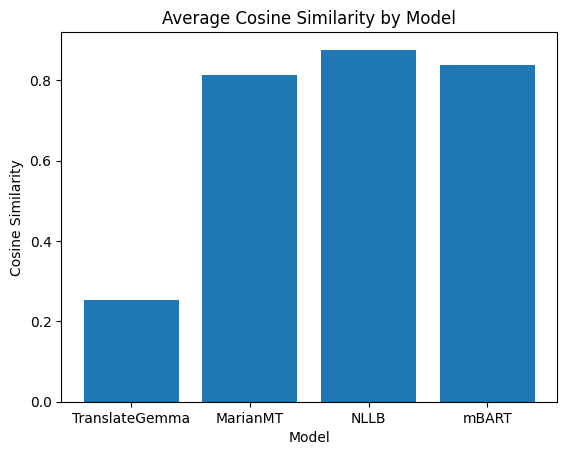

In [75]:
import matplotlib.pyplot as plt

plt.figure()

plt.bar(summary["Model"], summary["Average_Cosine_Similarity"])

plt.title("Average Cosine Similarity by Model")
plt.xlabel("Model")
plt.ylabel("Cosine Similarity")

plt.show()

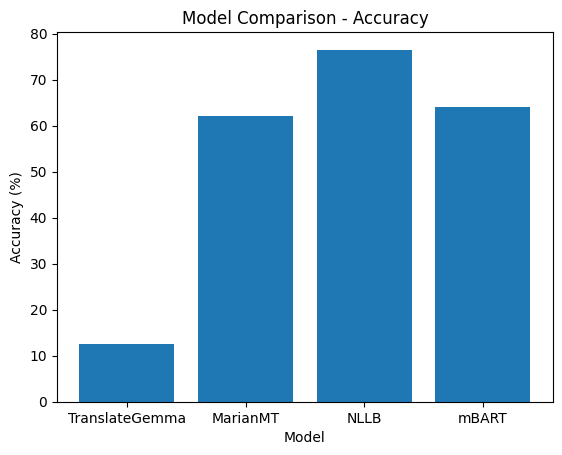

In [63]:
import matplotlib.pyplot as plt

summary = summary.reset_index(drop=True)

plt.figure()

plt.bar(summary["Model"], summary["Accuracy_Percentage"])

plt.title("Model Comparison - Accuracy")
plt.xlabel("Model")
plt.ylabel("Accuracy (%)")

plt.show()

In [64]:
low_cases = comparison.sort_values(by="sim_marian").head(5)

low_cases[[
    "en_original",
    "back_gemma", "sim_gemma",
    "back_marian", "sim_marian",
    "back_nllb", "sim_nllb",
    "back_mbart", "sim_mbart"
]]

,en_original,back_gemma,sim_gemma,back_marian,sim_marian,back_nllb,sim_nllb,back_mbart,sim_mbart
152,Congratulations!,NaN,0.0573,Killers!,0.1471,Congratulations!,1.0000,Greetings!,0.4006
193,Nothing is beautiful but the truth.,NaN,0.1362,What is the Inevitable Reality?,0.1726,Nothing is beautiful but the truth.,1.0000,Nothing is beautiful but the truth.,1.0000
196,This is a pun.,NaN,0.2075,It's a crazy.,0.2250,It's a gamble.,0.3088,It 's a joke.,0.4023
73,I think it is best not to be impolite.,NaN,0.0591,I think it's better not to be impossible.,0.2759,I think it is best not to be dishonest.,0.3545,I think it 's best not to be awkward.,0.5143
17,I make €100 a day.,I earn 100 euros every day.,0.8614,I'll make a day.,0.2831,I earn 100 euros a day.,0.8735,I earn 100 euros a day.,0.8735


In [73]:
subset = comparison.sort_values(by="sim_marian").head(5)  # worst
subset = pd.concat([
    subset,
    comparison.sort_values(by="sim_marian", ascending=False).head(5)  # best
])

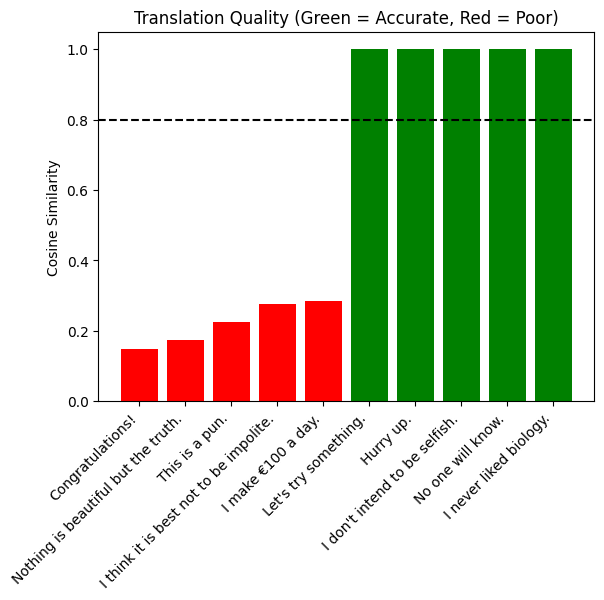

In [74]:
colors = ["green" if x >= 0.8 else "red" for x in subset["sim_marian"]]

plt.figure()

plt.bar(subset["en_original"], subset["sim_marian"], color=colors)

plt.axhline(y=0.8, color='black', linestyle='--', label='Threshold')

plt.xticks(rotation=45, ha="right")
plt.title("Translation Quality (Green = Accurate, Red = Poor)")
plt.ylabel("Cosine Similarity")

plt.show()